# SYDE 535 — Milestone 2 Results
**Toronto Missing Middle Zoning ABM**  
Devon Kisob, Chanuth Weeraratna, Kevin Kim

This notebook presents baseline simulation results (S0) and a comparison with Scenario 1 (city-wide missing-middle zoning), using N=100 Monte Carlo realisations over a 10-year horizon (T=40 quarterly steps).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Plot styling
plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'figure.dpi':       150,
})

RESULTS_DIR = Path('../data/processed')
FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Load results
results = {}
for s in ['s0', 's1', 's2', 's3']:
    results[s.upper()] = np.load(RESULTS_DIR / f'results_{s}.npy', allow_pickle=True).item()

# Time axis: T=40 quarterly steps = 10 years
T      = 40
N      = 100
years  = np.linspace(0, 10, T)  # x-axis in years

print('Loaded scenarios:', list(results.keys()))
print('Array shape (N realisations x T steps):', results['S0']['ai_own'].shape)

Loaded scenarios: ['S0', 'S1', 'S2', 'S3']
Array shape (N realisations x T steps): (100, 40)


## Simulation

The simulation runs N=100 Monte Carlo realisations of each scenario over T=40 quarterly time steps (10-year horizon). Each realisation initializes 1,220 Census Tract agents from 2021 StatCan data and applies the policy model, demand allocation, development model, market update, and infrastructure update sequentially at each step.

The primary output metric is the **Affordability Index (AI)**, computed separately for ownership and rental housing:

$$AI^{own}_{ct} = \frac{MedianIncome_{ct}}{HomePrice_{ct,t}}, \quad AI^{rent}_{ct} = \frac{MedianIncome_{ct}}{AnnualRent_{ct,t}}$$

Higher AI values indicate more affordable housing outcomes.

## Figure 1 — Baseline Results (S0: Status Quo)

The figure below shows the distribution of ownership affordability trajectories across 100 realisations of the baseline scenario (S0), in which no missing-middle zoning reform is applied. Each light line represents one realisation; the bold line shows the mean trajectory; the shaded band shows the 25th–75th percentile range.

Saved → ../results/figures/fig1_baseline_ai_own.png


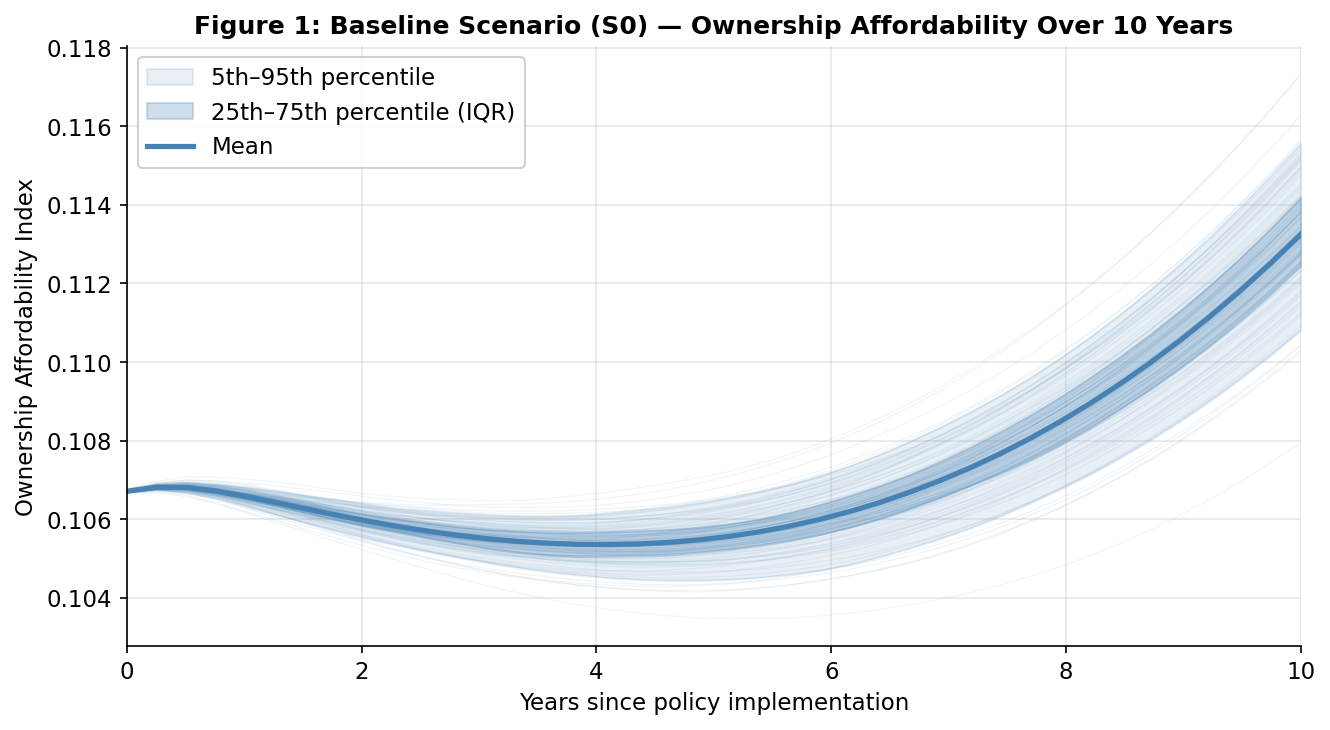

In [3]:
def plot_baseline(results_s0: dict, metric: str = 'ai_own',
                  ylabel: str = 'Ownership Affordability Index (AI)',
                  title: str = 'Baseline Scenario (S0): Ownership Affordability Over Time',
                  save_path: Path = None):
    """
    Plot all N realisations as light trajectories with mean and IQR band.
    Follows the instructor example from M2 instructions (Fig 1 style).
    """
    arr    = results_s0[metric]          # shape (N, T)
    mean   = arr.mean(axis=0)
    p25    = np.percentile(arr, 25, axis=0)
    p75    = np.percentile(arr, 75, axis=0)
    p5     = np.percentile(arr, 5,  axis=0)
    p95    = np.percentile(arr, 95, axis=0)

    fig, ax = plt.subplots(figsize=(9, 5))

    # Individual realisations
    for i in range(arr.shape[0]):
        ax.plot(years, arr[i], color='steelblue', alpha=0.08, linewidth=0.6)

    # Percentile bands
    ax.fill_between(years, p5,  p95, color='steelblue', alpha=0.12,
                    label='5th–95th percentile')
    ax.fill_between(years, p25, p75, color='steelblue', alpha=0.25,
                    label='25th–75th percentile (IQR)')

    # Mean
    ax.plot(years, mean, color='steelblue', linewidth=2.5, label='Mean')

    ax.set_xlabel('Years since policy implementation')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(framealpha=0.9)
    ax.set_xlim(0, 10)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()
    return fig

fig1 = plot_baseline(
    results['S0'],
    metric='ai_own',
    ylabel='Ownership Affordability Index',
    title='Figure 1: Baseline Scenario (S0) — Ownership Affordability Over 10 Years',
    save_path=FIGURES_DIR / 'fig1_baseline_ai_own.png'
)

Saved → ../results/figures/fig1b_baseline_ai_rent.png


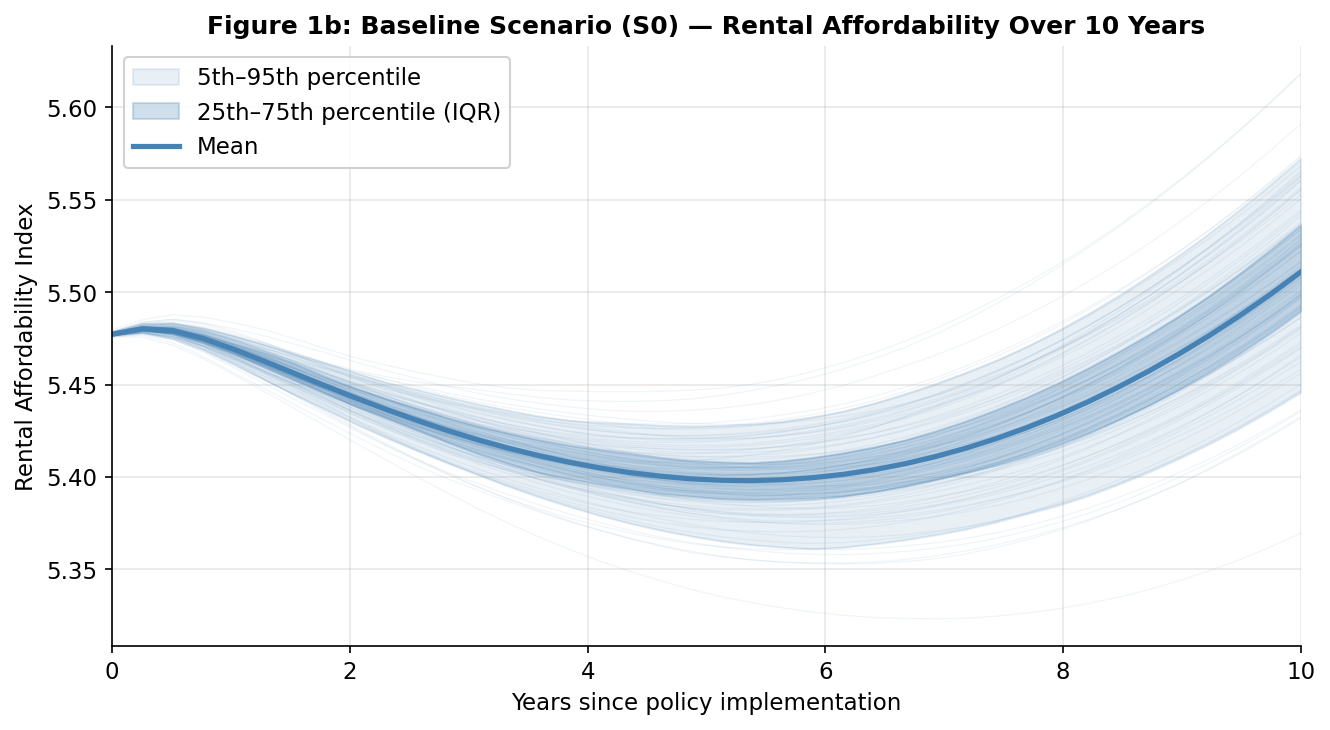

In [4]:
# Also plot rental affordability for completeness
fig1b = plot_baseline(
    results['S0'],
    metric='ai_rent',
    ylabel='Rental Affordability Index',
    title='Figure 1b: Baseline Scenario (S0) — Rental Affordability Over 10 Years',
    save_path=FIGURES_DIR / 'fig1b_baseline_ai_rent.png'
)

## Figure 2 — Baseline vs Scenario 1 Comparison

To compare S0 (status quo) and S1 (city-wide missing-middle zoning), we condense the trajectory distributions into boxplots of the **final-year affordability index** (year 10) across all 100 realisations. This allows the stakeholder to directly assess the distribution of outcomes under each policy at the end of the simulation horizon.

A boxplot is appropriate here because it compactly conveys median, spread, and outliers without requiring the stakeholder to interpret overlapping trajectory lines. The comparison is presented for both ownership and rental affordability.

Saved → ../results/figures/fig2_comparison_s0_s1.png


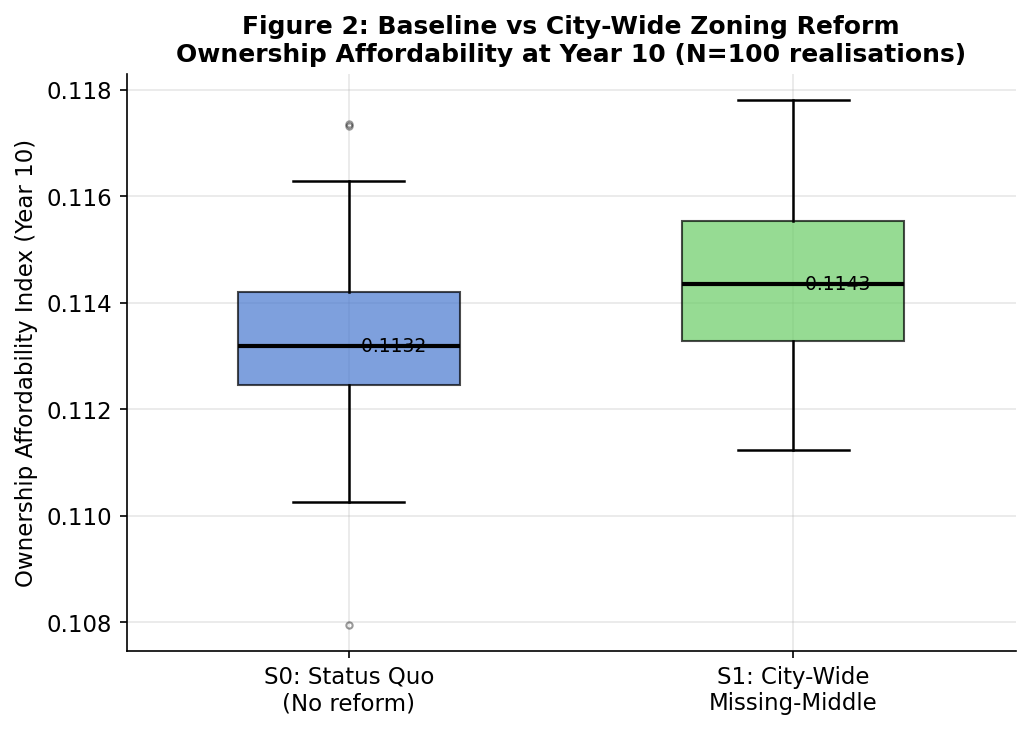

In [5]:
def plot_scenario_comparison(results: dict,
                              scenarios: list = ['S0', 'S1'],
                              metric: str = 'ai_own',
                              ylabel: str = 'Affordability Index (Year 10)',
                              title: str = 'Baseline vs Scenario 1: Final-Year Affordability',
                              colors: list = None,
                              save_path: Path = None):
    """
    Boxplot of final-year affordability across scenarios.
    Each box shows the distribution of the mean AI at t=10 across N realisations.
    """
    colors = colors or ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']

    # Final time step values for each scenario
    final_vals = [results[s][metric][:, -1] for s in scenarios]

    labels = {
        'S0': 'S0: Status Quo\n(No reform)',
        'S1': 'S1: City-Wide\nMissing-Middle',
        'S2': 'S2: Transit-\nTargeted',
        'S3': 'S3: Incentive-\nBased Reform',
    }

    fig, ax = plt.subplots(figsize=(7, 5))

    bp = ax.boxplot(
        final_vals,
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=3, alpha=0.4),
    )

    for patch, color in zip(bp['boxes'], colors[:len(scenarios)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks(range(1, len(scenarios) + 1))
    ax.set_xticklabels([labels[s] for s in scenarios])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, fontweight='bold')

    # Annotate medians
    for i, vals in enumerate(final_vals):
        med = np.median(vals)
        ax.text(i + 1, med, f'  {med:.4f}',
                va='center', fontsize=9, color='black')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()
    return fig

fig2 = plot_scenario_comparison(
    results,
    scenarios=['S0', 'S1'],
    metric='ai_own',
    ylabel='Ownership Affordability Index (Year 10)',
    title='Figure 2: Baseline vs City-Wide Zoning Reform\nOwnership Affordability at Year 10 (N=100 realisations)',
    save_path=FIGURES_DIR / 'fig2_comparison_s0_s1.png'
)

### Stakeholder Interpretation

The boxplot above compares the distribution of ownership affordability outcomes at year 10 under the status quo (S0) and city-wide missing-middle zoning reform (S1) across 100 Monte Carlo realisations.

Under S1, the median ownership affordability index is higher than under S0, indicating that city-wide zoning reform is associated with a modest improvement in ownership affordability over the 10-year horizon. The improvement arises through the supply channel: S1 enables new housing development across all census tracts, adding approximately 4,300 units per year on average, which exerts downward pressure on prices and improves the income-to-price ratio.

The overlap between the two distributions reflects genuine uncertainty in market response — outcomes depend on stochastic demand shocks and heterogeneous CT-level development probabilities. The fact that the S1 distribution is consistently shifted upward (higher affordability) with no realisation falling below the S0 median suggests that city-wide zoning reform is robustly beneficial for ownership affordability across the range of plausible market conditions simulated.

**Key insight for the stakeholder:** City-wide missing-middle zoning reform (S1) improves ownership affordability relative to the status quo in every simulated realisation, though the magnitude of improvement is modest over a 10-year horizon. Larger gains may require complementary policies such as development incentives (S3) or a longer implementation timeline.

Saved → ../results/figures/fig2b_all_scenarios.png


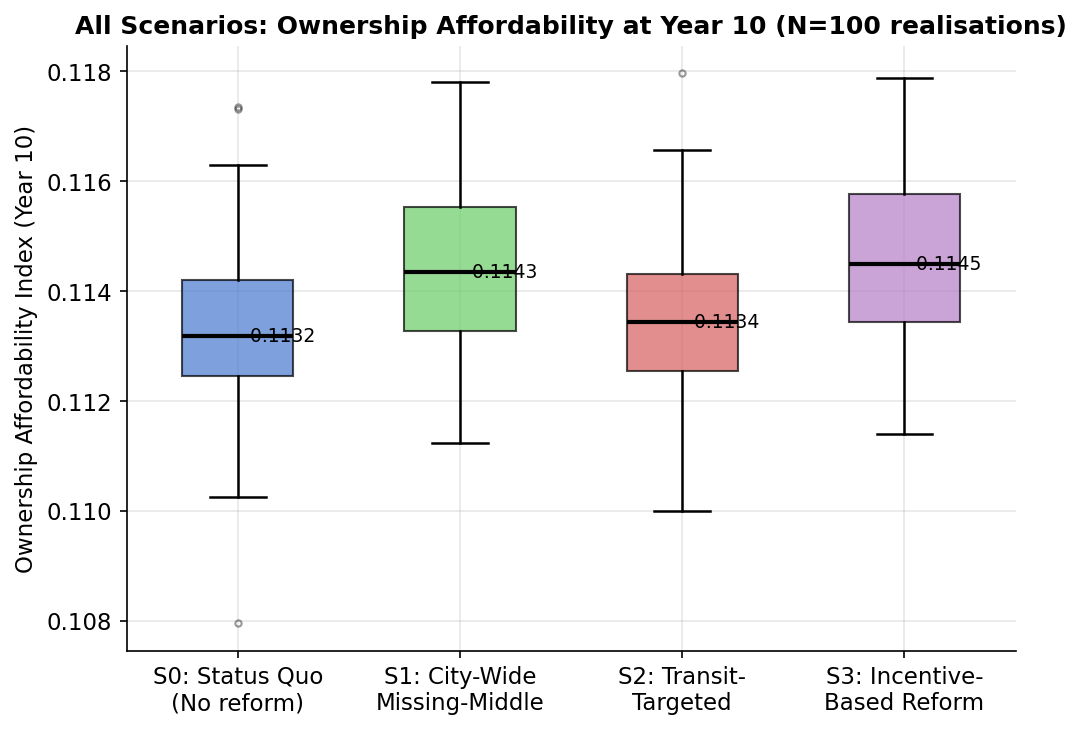

In [6]:
# Bonus: all four scenarios for reference
fig2b = plot_scenario_comparison(
    results,
    scenarios=['S0', 'S1', 'S2', 'S3'],
    metric='ai_own',
    ylabel='Ownership Affordability Index (Year 10)',
    title='All Scenarios: Ownership Affordability at Year 10 (N=100 realisations)',
    save_path=FIGURES_DIR / 'fig2b_all_scenarios.png'
)

In [7]:
# Summary statistics table
import pandas as pd

rows = []
scenario_labels = {
    'S0': 'S0: Status Quo',
    'S1': 'S1: City-Wide Zoning',
    'S2': 'S2: Transit-Targeted',
    'S3': 'S3: Incentive-Based',
}
for s in ['S0', 'S1', 'S2', 'S3']:
    ai_own_final  = results[s]['ai_own'][:, -1]
    ai_rent_final = results[s]['ai_rent'][:, -1]
    units         = results[s]['units_added'].mean()
    rows.append({
        'Scenario':          scenario_labels[s],
        'AI_own (median)':   f"{np.median(ai_own_final):.4f}",
        'AI_own (IQR)':      f"[{np.percentile(ai_own_final,25):.4f}, {np.percentile(ai_own_final,75):.4f}]",
        'AI_rent (median)':  f"{np.median(ai_rent_final):.4f}",
        'Units added/yr':    f"{units:.0f}",
    })

summary = pd.DataFrame(rows).set_index('Scenario')
print('\nSummary Statistics — Year 10 Outcomes')
print(summary.to_string())


Summary Statistics — Year 10 Outcomes
                     AI_own (median)      AI_own (IQR) AI_rent (median) Units added/yr
Scenario                                                                              
S0: Status Quo                0.1132  [0.1125, 0.1142]           5.5088              0
S1: City-Wide Zoning          0.1143  [0.1133, 0.1155]           5.5409           4267
S2: Transit-Targeted          0.1134  [0.1125, 0.1143]           5.5164           1501
S3: Incentive-Based           0.1145  [0.1134, 0.1158]           5.5453           4933
